In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class QuadState(TypedDict):

    a : int
    b : int
    c : int

    equation : str
    discriminant : float
    result : str


In [5]:
def show_equation(state: QuadState) -> QuadState:

    eq = f"({state['a']})x2 + ({state['b']})x + ({state['c']})"

    return {"equation" : eq}


def cal_discriminant(state : QuadState) -> QuadState:

    d = ((state['b'])**2) - (4*(state['a'])*(state['c']))

    return {"discriminant" : d}

In [6]:
def real_roots(state : QuadState) -> QuadState:

    root1 = ((-state['b']) + (state['discriminant']**0.5)) / (2*state['a'])
    root2 = ((-state['b']) - (state['discriminant']**0.5)) / (2*state['a'])

    ans = f"root 1 is :: {round(root1,2)} and root 2 is :: {round(root2,2)}"

    return {"result" : ans}


def repeated_roots(state : QuadState) -> QuadState:
    root = (-state['b'])  / (2*state['a'])
    
    ans = f"root is :: {round(root,2)}"
    
    return {"result" : ans}


def no_real_roots(state : QuadState) -> QuadState:

    ans = f"There are no any root exist for this equation."
        
    return {"result" : ans}


In [8]:
def check_condition(state : QuadState) -> Literal["real_roots","repeated_roots","no_real_roots"]:

    if state["discriminant"] > 0:
        return "real_roots"
    elif state["discriminant"] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"

In [10]:
graph = StateGraph(QuadState)

graph.add_node("show_equation",show_equation)
graph.add_node("cal_discriminant",cal_discriminant)
graph.add_node("real_roots",real_roots)
graph.add_node("repeated_roots",repeated_roots)
graph.add_node("no_real_roots",no_real_roots)

graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","cal_discriminant")
graph.add_conditional_edges("cal_discriminant",check_condition)    # <---- main logic is here for condition.
graph.add_edge("real_roots",END) 
graph.add_edge("repeated_roots",END) 
graph.add_edge("no_real_roots",END) 

workflow = graph.compile()

In [11]:
# execute the graph
initial_state = {"a" : 1, "b" : -5, "c" : 6}

final_state = workflow.invoke(initial_state)

print(final_state)

{'a': 1, 'b': -5, 'c': 6, 'equation': '(1)x2 + (-5)x + (6)', 'discriminant': 1, 'result': 'root 1 is :: 3.0 and root 2 is :: 2.0'}


In [12]:
# execute the graph
initial_state = {"a" : 1, "b" : -4, "c" : 4}

final_state = workflow.invoke(initial_state)

print(final_state)

{'a': 1, 'b': -4, 'c': 4, 'equation': '(1)x2 + (-4)x + (4)', 'discriminant': 0, 'result': 'root is :: 2.0'}


In [13]:
# execute the graph
initial_state = {"a" : 1, "b" : -2, "c" : 3}

final_state = workflow.invoke(initial_state)

print(final_state)

{'a': 1, 'b': -2, 'c': 3, 'equation': '(1)x2 + (-2)x + (3)', 'discriminant': -8, 'result': 'There are no any root exist for this equation.'}


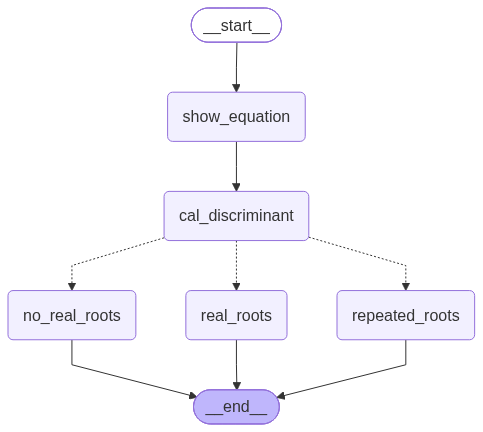

In [14]:
workflow